In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import kagglehub
kartik2112_fraud_detection_path = kagglehub.dataset_download('kartik2112/fraud-detection')

print('Data source import complete.')

100%|██████████| 202M/202M [00:07<00:00, 26.7MB/s]

Extracting files...


Data source import complete.


In [3]:
import os
x_train = pd.read_csv(os.path.join(kartik2112_fraud_detection_path, 'fraudTrain.csv'))
x_test = pd.read_csv(os.path.join(kartik2112_fraud_detection_path, 'fraudTest.csv'))

In [4]:
x_train.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [5]:
x_train.tail(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


In [6]:
x_test.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0


In [7]:
def shape_size(x):
  print("Shape ",x.shape)
  print("Size ",x.size)

In [8]:
shape_size(x_test)
shape_size(x_train)

Shape  (555719, 23)
Size  12781537
Shape  (1296675, 23)
Size  29823525


In [9]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [10]:
x_train.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [11]:
x_train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


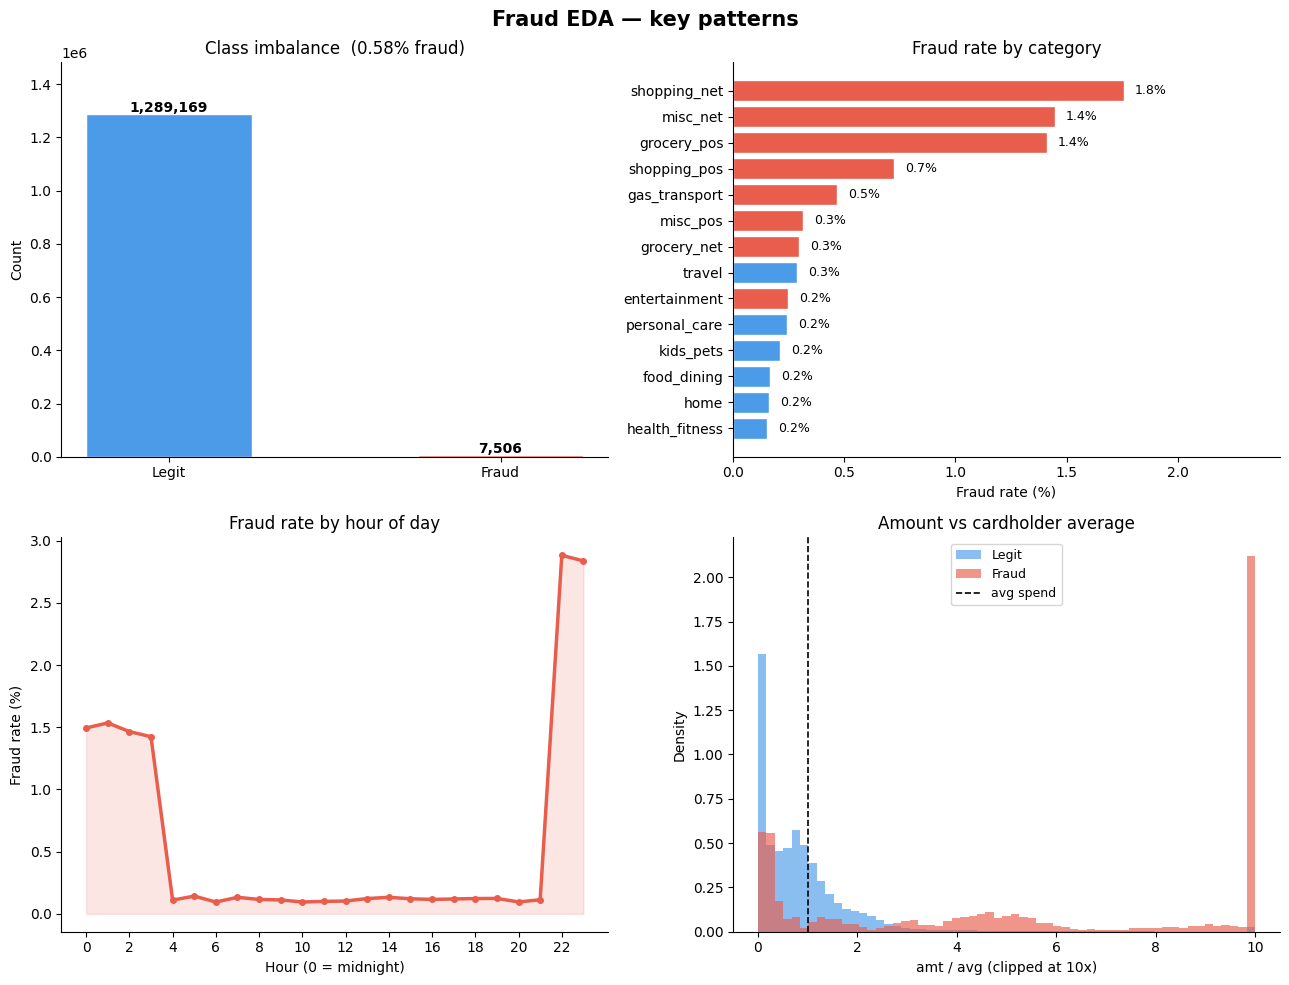

In [12]:
import matplotlib.pyplot as plt
CLR_LEGIT, CLR_FRAUD = '#4C9BE8', '#E85D4C'

_df = x_train.copy()
_df['trans_date_trans_time'] = pd.to_datetime(_df['trans_date_trans_time'])
_df['hour'] = _df['trans_date_trans_time'].dt.hour
card_avg = _df.groupby('cc_num')['amt'].transform('mean')
_df['amt_vs_avg'] = _df['amt'] / card_avg.replace(0, np.nan)
legit = _df[_df['is_fraud'] == 0]
fraud = _df[_df['is_fraud'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Fraud EDA — key patterns', fontsize=15, fontweight='bold')

counts = _df['is_fraud'].value_counts().sort_index()
bars = axes[0,0].bar(['Legit','Fraud'], counts.values,
                     color=[CLR_LEGIT, CLR_FRAUD], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   val + 8000, f'{val:,}', ha='center', fontweight='bold')
axes[0,0].set_title(f'Class imbalance  ({counts[1]/counts.sum()*100:.2f}% fraud)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_ylim(0, counts.max() * 1.15)
axes[0,0].spines[['top','right']].set_visible(False)

cat_rate = (_df.groupby('category')['is_fraud'].mean() * 100).sort_values()
HIGH_RISK = {'misc_net','grocery_pos','gas_transport','entertainment',
             'grocery_net','shopping_net','shopping_pos','misc_pos'}
colors = [CLR_FRAUD if c in HIGH_RISK else CLR_LEGIT for c in cat_rate.index]
axes[0,1].barh(cat_rate.index, cat_rate.values, color=colors, edgecolor='white')
for i, val in enumerate(cat_rate.values):
    axes[0,1].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=9)
axes[0,1].set_title('Fraud rate by category')
axes[0,1].set_xlabel('Fraud rate (%)')
axes[0,1].set_xlim(0, cat_rate.max() * 1.4)
axes[0,1].spines[['top','right']].set_visible(False)


hourly = _df.groupby('hour')['is_fraud'].mean() * 100
axes[1,0].plot(hourly.index, hourly.values, color=CLR_FRAUD,
               linewidth=2.5, marker='o', markersize=4)
axes[1,0].fill_between(hourly.index, hourly.values, alpha=0.15, color=CLR_FRAUD)
axes[1,0].set_title('Fraud rate by hour of day')
axes[1,0].set_xlabel('Hour (0 = midnight)')
axes[1,0].set_ylabel('Fraud rate (%)')
axes[1,0].set_xticks(range(0, 24, 2))
axes[1,0].spines[['top','right']].set_visible(False)

ratio_bins = np.linspace(0, 10, 60)
for data, label, color in [(legit,'Legit',CLR_LEGIT),(fraud,'Fraud',CLR_FRAUD)]:
    axes[1,1].hist(data['amt_vs_avg'].clip(upper=10), bins=ratio_bins,
                   alpha=0.65, label=label, color=color,
                   density=True, edgecolor='none')
axes[1,1].axvline(1.0, color='black', linewidth=1.2,
                  linestyle='--', label='avg spend')
axes[1,1].set_title('Amount vs cardholder average')
axes[1,1].set_xlabel('amt / avg (clipped at 10x)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend(fontsize=9)
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('section1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
x_train.duplicated().sum()

np.int64(0)

In [14]:
x_train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [15]:
x_train.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [16]:
'''

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


['age','cc_num_id','cc_num_freq',
,'merchant', 'category','job','amt','gender','dist','city_pop',,'amt_avg'
,'high_risk_cat','is_fraud']

'''
print(x_train.loc[5, 'trans_date_trans_time'])
print(pd.to_datetime(x_train.loc[5, 'trans_date_trans_time']))
print(x_train['job'].nunique())

2019-01-01 00:04:08
2019-01-01 00:04:08
494


In [17]:
x_train['trans_date_trans_time']=pd.to_datetime(x_train['trans_date_trans_time'])
x_test['trans_date_trans_time']=pd.to_datetime(x_test['trans_date_trans_time'])
x_train['dob']=pd.to_datetime(x_train['dob'])
x_test['dob']=pd.to_datetime(x_test['dob'])
x_train['age']=(x_train['trans_date_trans_time']-x_train['dob']).dt.days//365
x_test['age']=(x_test['trans_date_trans_time']-x_test['dob']).dt.days//365


In [18]:
# 'hour','day_of_week','month','is_weekend'
x_train['hour']=x_train['trans_date_trans_time'].dt.hour
x_train['day_of_week']=x_train['trans_date_trans_time'].dt.dayofweek
x_train['month']=x_train['trans_date_trans_time'].dt.month
x_train['is_weekend']=x_train['day_of_week'].isin([5,6]).astype(int)
x_test['hour']=x_test['trans_date_trans_time'].dt.hour
x_test['day_of_week']=x_test['trans_date_trans_time'].dt.dayofweek
x_test['month']=x_test['trans_date_trans_time'].dt.month
x_test['is_weekend']=x_test['day_of_week'].isin([5,6]).astype(int)

In [19]:
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[['cc_num']] = enc.fit_transform(x_train[['cc_num']])
x_test[['cc_num']] = enc.transform(x_test[['cc_num']])

cc_freq = x_train['cc_num'].value_counts()
x_train['cc_num_freq'] = x_train['cc_num'].map(cc_freq)
x_test['cc_num_freq']  = x_test['cc_num'].map(cc_freq).fillna(0)

In [20]:
enc_gen = LabelEncoder()
enc_gen.fit(x_train['gender'].astype(str))


x_train['gender'] = enc_gen.transform(x_train['gender'].astype(str))

mapping = {c: i for i, c in enumerate(enc_gen.classes_)}
x_test['gender'] = x_test['gender'].astype(str).map(mapping).fillna(-1).astype(int)


In [21]:
cat=x_train['category'].value_counts()
x_train['cat_freq']=x_train['category'].map(cat)
x_test['cat_freq']=x_test['category'].map(cat).fillna(0)

In [22]:
merc=x_train['merchant'].value_counts()
x_train['merc_freq']=x_train['merchant'].map(merc)
x_test['merc_freq']=x_test['merchant'].map(merc).fillna(0)

In [23]:
job=x_train['job'].value_counts()
x_train['job']=x_train['job'].map(job)
x_test['job']=x_test['job'].map(job).fillna(0)

In [24]:
def haversine(lat1, long1, lat2, long2):
    R = 6371

    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2])

    dlat  = lat2 - lat1
    dlong = long2 - long1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlong/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

x_train['dist'] = haversine(
    x_train['lat'],      x_train['long'],
    x_train['merch_lat'],x_train['merch_long']
)
x_test['dist'] = haversine(
    x_test['lat'],      x_test['long'],
    x_test['merch_lat'],x_test['merch_long']
)

In [25]:
card_avg=x_train.groupby('cc_num')['amt'].mean()
overall_avg = x_train['amt'].mean()

x_train['avg_amt']=x_train['cc_num'].map(card_avg)
x_test['avg_amt']=x_test['cc_num'].map(card_avg).fillna(overall_avg)

x_test['amt_vs_avg']=x_test['amt']/x_test['avg_amt']
x_train['amt_vs_avg']=x_train['amt']/x_train['avg_amt']

x_train.drop(columns=['avg_amt'],inplace=True)
x_test.drop(columns=['avg_amt'],inplace=True)

In [26]:
x_train['category'].unique()
high_risk=['misc_net', 'grocery_pos','gas_transport','entertainment','grocery_net', 'shopping_net', 'shopping_pos','misc_pos']
x_train['high_risk_cat']=x_train['category'].isin(high_risk).astype(int)
x_test['high_risk_cat']=x_test['category'].isin(high_risk).astype(int)


In [27]:
x_train['amt']=np.log1p(x_train['amt'])
x_test['amt']=np.log1p(x_test['amt'])

x_train['city_pop']=np.log1p(x_train['city_pop'])
x_test['city_pop']=np.log1p(x_test['city_pop'])

In [28]:
y_train=x_train['is_fraud']
y_test=x_test['is_fraud']

In [29]:
'''
Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'age', 'hour', 'day_of_week',
       'month', 'is_weekend', 'cc_num', 'cc_num_freq', 'cat_freq',
       'merc_freq', 'dist', 'amt_vs_avg', 'high_risk_cat'],
      dtype='object')

'''
drop_col=['Unnamed: 0','cc_num','trans_date_trans_time','merchant','category',
          'first', 'last', 'street','is_fraud', 'city', 'state', 'zip',
       'lat', 'long','dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long']

x_train.drop(columns=drop_col,inplace=True)
x_test.drop(columns=drop_col,inplace=True)


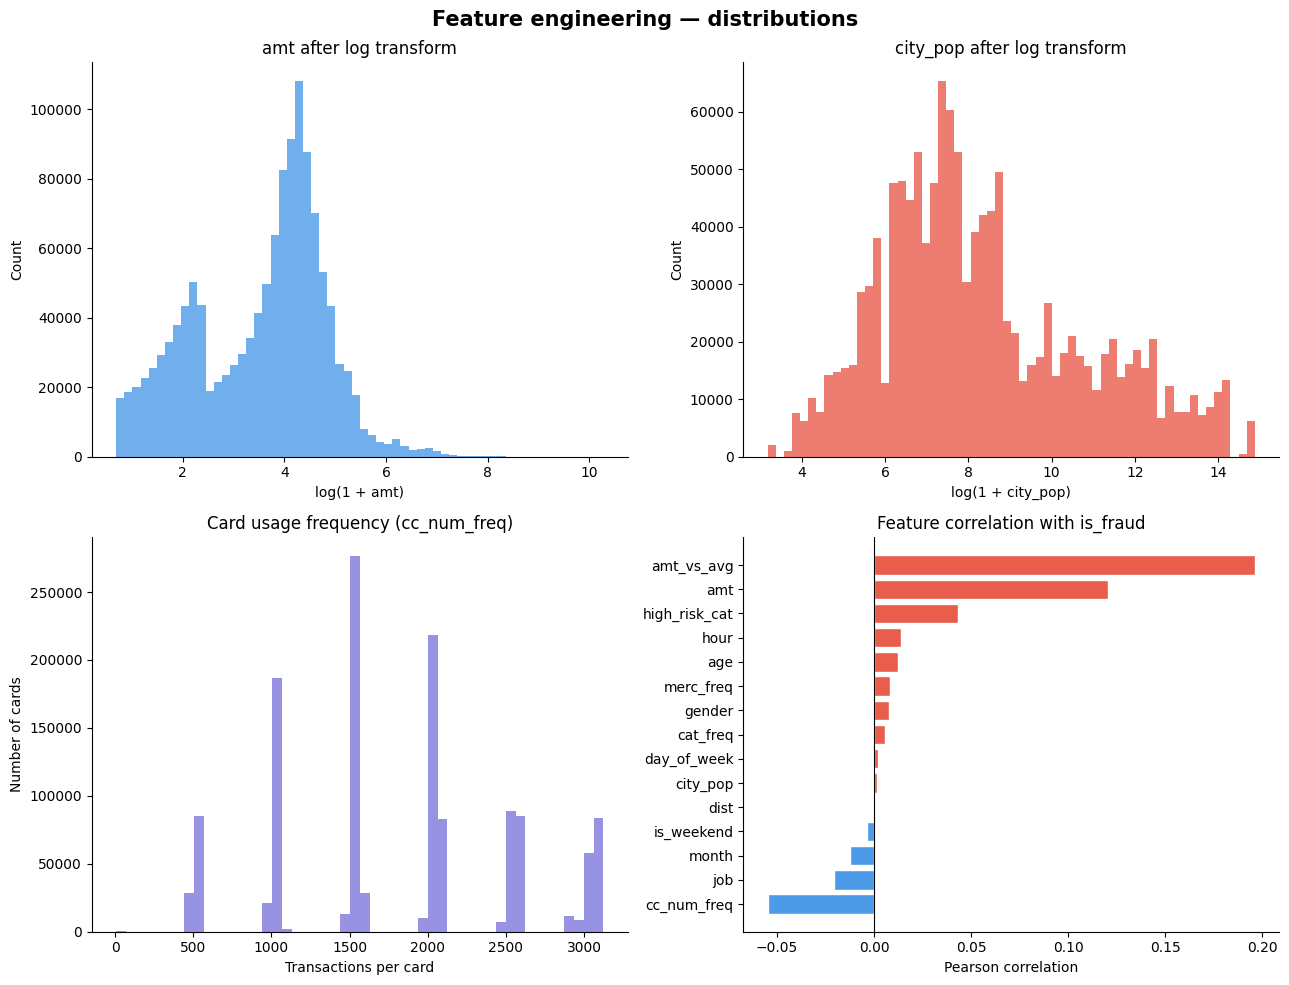

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Feature engineering — distributions', fontsize=15, fontweight='bold')


axes[0,0].hist(x_train['amt'], bins=60,
               color=CLR_LEGIT, alpha=0.8, edgecolor='none')
axes[0,0].set_title('amt after log transform')
axes[0,0].set_xlabel('log(1 + amt)')
axes[0,0].set_ylabel('Count')
axes[0,0].spines[['top','right']].set_visible(False)

axes[0,1].hist(x_train['city_pop'], bins=60,
               color=CLR_FRAUD, alpha=0.8, edgecolor='none')
axes[0,1].set_title('city_pop after log transform')
axes[0,1].set_xlabel('log(1 + city_pop)')
axes[0,1].set_ylabel('Count')
axes[0,1].spines[['top','right']].set_visible(False)

axes[1,0].hist(x_train['cc_num_freq'], bins=50,
               color='#7F77DD', alpha=0.8, edgecolor='none')
axes[1,0].set_title('Card usage frequency (cc_num_freq)')
axes[1,0].set_xlabel('Transactions per card')
axes[1,0].set_ylabel('Number of cards')
axes[1,0].spines[['top','right']].set_visible(False)

feat_cols = ['amt','gender','city_pop','job','age','hour','day_of_week',
             'month','is_weekend','cc_num_freq','cat_freq',
             'merc_freq','dist','amt_vs_avg','high_risk_cat']
corr = x_train[feat_cols].corrwith(y_train).sort_values()
colors_corr = [CLR_FRAUD if v > 0 else CLR_LEGIT for v in corr.values]
axes[1,1].barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
axes[1,1].axvline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Feature correlation with is_fraud')
axes[1,1].set_xlabel('Pearson correlation')
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('section2_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
'''
Index(['amt', 'gender', 'city_pop', 'job', 'is_fraud', 'age', 'hour',
       'day_of_week', 'month', 'is_weekend', 'cc_num_id', 'cc_num_freq',
       'cat_freq', 'merc_freq', 'dist', 'amt_vs_avg', 'high_risk_cat'],
      dtype='object')

'''
shape_size(x_train)
shape_size(x_test)

Shape  (1296675, 15)
Size  19450125
Shape  (555719, 15)
Size  8335785


In [32]:
cols = ['amt','amt_vs_avg','dist','age','cc_num_freq']

for c in cols:
    print("COLUMN:", c)
    print(x_train[c].describe())
    print("Top 5 values:", x_train[c].nlargest(5).values)
    print("Bottom 5 values:", x_train[c].nsmallest(5).values)
    print("-"*40)

COLUMN: amt
count    1.296675e+06
mean     3.533470e+00
std      1.289448e+00
min      6.931472e-01
25%      2.365560e+00
50%      3.881976e+00
75%      4.432482e+00
max      1.027332e+01
Name: amt, dtype: float64
Top 5 values: [10.27332203 10.21797415 10.20805513 10.18660121 10.13014253]
Bottom 5 values: [0.69314718 0.69314718 0.69314718 0.69314718 0.69314718]
----------------------------------------
COLUMN: amt_vs_avg
count    1.296675e+06
mean     1.000000e+00
std      2.299918e+00
min      8.693369e-03
25%      1.544154e-01
50%      6.694151e-01
75%      1.187412e+00
max      3.864816e+02
Name: amt_vs_avg, dtype: float64
Top 5 values: [386.48158826 358.59623936 283.02078651 248.47441151 236.15168217]
Bottom 5 values: [0.00869337 0.00877907 0.0092994  0.00938752 0.00953471]
----------------------------------------
COLUMN: dist
count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max 

In [33]:
from sklearn.preprocessing import RobustScaler

scalar=RobustScaler()
scalar.fit(x_train)

x_train=scalar.transform(x_train)
x_test=scalar.transform(x_test)

In [34]:
from sklearn.linear_model import LogisticRegression
reg=LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
reg.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [35]:
y_pred=reg.predict(x_test)

In [36]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.04      0.74      0.07      2145

    accuracy                           0.93    555719
   macro avg       0.52      0.84      0.52    555719
weighted avg       1.00      0.93      0.96    555719

[[514609  38965]
 [   548   1597]]


In [37]:
import gc
gc.collect()

80

In [38]:
import psutil
ram = psutil.virtual_memory()
print(f'Used: {ram.used/1e9:.1f} GB')
print(f'Available: {ram.available/1e9:.1f} GB')

Used: 3.1 GB
Available: 10.2 GB


In [39]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=35,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.23      0.93      0.36      2145

    accuracy                           0.99    555719
   macro avg       0.61      0.96      0.68    555719
weighted avg       1.00      0.99      0.99    555719

[[546785   6789]
 [   153   1992]]


In [40]:

from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=99,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.71      0.83      0.77      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.92      0.88    555719
weighted avg       1.00      1.00      1.00    555719

[[552831    743]
 [   354   1791]]


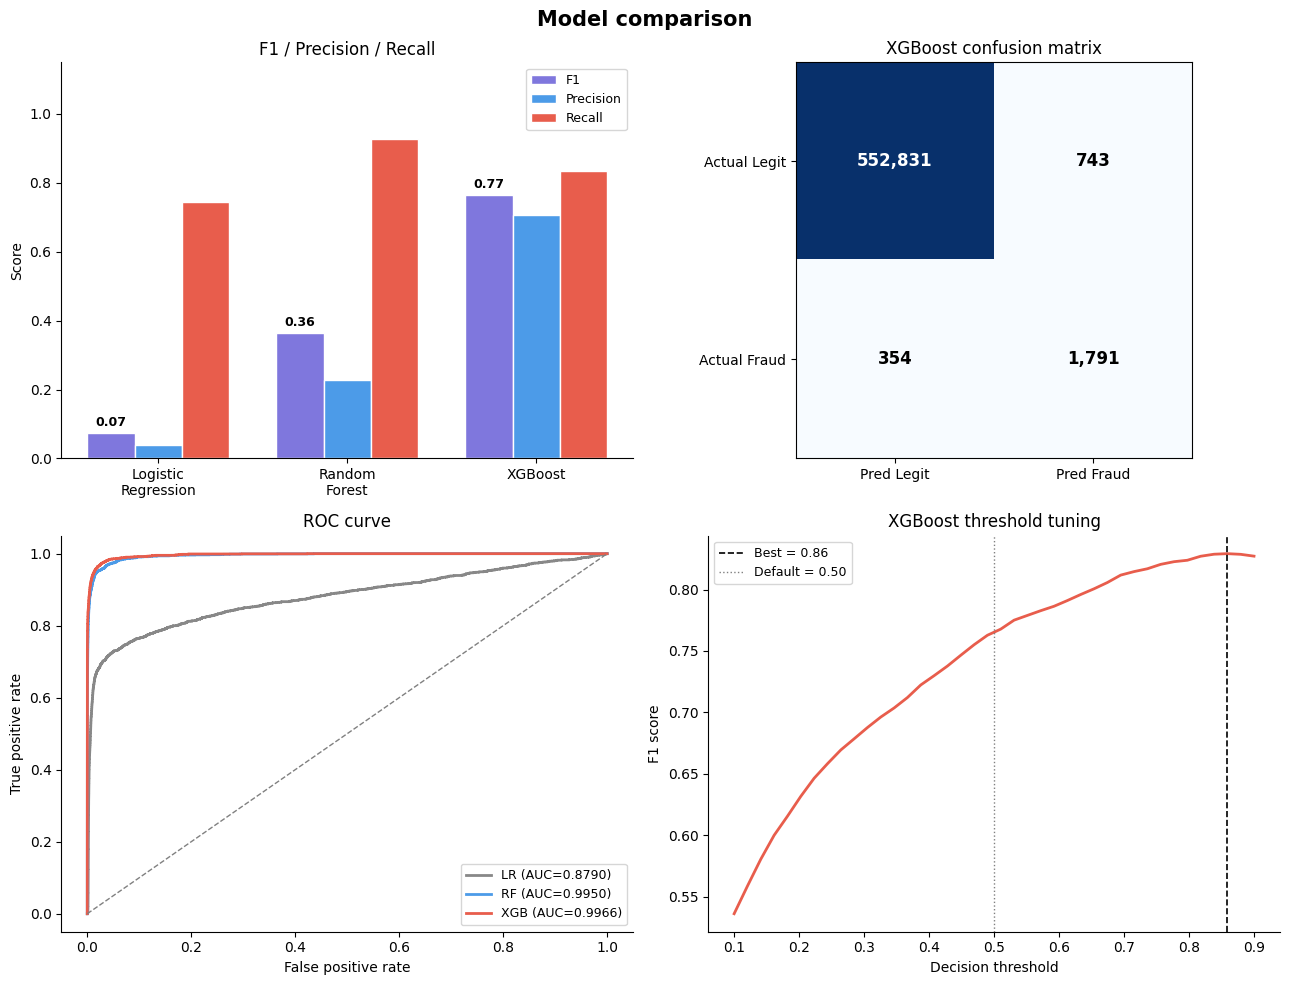

Best threshold: 0.86  →  F1 = 0.829


In [41]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, auc)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Model comparison', fontsize=15, fontweight='bold')

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
preds  = [y_pred, y_pred_rf, y_pred_xgb]

f1s   = [f1_score(y_test, p) for p in preds]
precs = [precision_score(y_test, p, zero_division=0) for p in preds]
recs  = [recall_score(y_test, p) for p in preds]

x = np.arange(3)
w = 0.25

axes[0,0].bar(x - w, f1s, width=w, label='F1', color='#7F77DD', edgecolor='white')
axes[0,0].bar(x, precs, width=w, label='Precision', color=CLR_LEGIT, edgecolor='white')
axes[0,0].bar(x + w, recs, width=w, label='Recall', color=CLR_FRAUD, edgecolor='white')

axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('F1 / Precision / Recall')
axes[0,0].legend(fontsize=9)
axes[0,0].spines[['top','right']].set_visible(False)

for i, f in enumerate(f1s):
    axes[0,0].text(i - w, f + 0.02, f'{f:.2f}',
                   ha='center', fontsize=9, fontweight='bold')


cm = confusion_matrix(y_test, y_pred_xgb)

axes[0,1].imshow(cm, cmap='Blues')
axes[0,1].set_xticks([0,1])
axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Pred Legit', 'Pred Fraud'])
axes[0,1].set_yticklabels(['Actual Legit', 'Actual Fraud'])
axes[0,1].set_title('XGBoost confusion matrix')

for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, f'{cm[i,j]:,}',
                       ha='center', va='center',
                       fontsize=12, fontweight='bold',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')


proba_lr  = reg.predict_proba(x_test)[:,1]
proba_rf  = model_rf.predict_proba(x_test)[:,1]
proba_xgb = model_xgb.predict_proba(x_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)

auc_lr  = auc(fpr_lr, tpr_lr)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

axes[1,0].plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc_lr:.4f})', linewidth=2, color='#888888')
axes[1,0].plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc_rf:.4f})', linewidth=2, color=CLR_LEGIT)
axes[1,0].plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={auc_xgb:.4f})', linewidth=2, color=CLR_FRAUD)

axes[1,0].plot([0,1],[0,1], '--', color='gray', linewidth=1)

axes[1,0].set_xlabel('False positive rate')
axes[1,0].set_ylabel('True positive rate')
axes[1,0].set_title('ROC curve')
axes[1,0].legend(fontsize=9)
axes[1,0].spines[['top','right']].set_visible(False)


thresholds = np.linspace(0.1, 0.9, 40)

f1_scores = [
    f1_score(y_test, (proba_xgb >= t).astype(int))
    for t in thresholds
]

best_t = thresholds[np.argmax(f1_scores)]

axes[1,1].plot(thresholds, f1_scores, color=CLR_FRAUD, linewidth=2)

axes[1,1].axvline(best_t, color='black', linewidth=1.2,
                  linestyle='--', label=f'Best = {best_t:.2f}')

axes[1,1].axvline(0.5, color='gray', linewidth=1,
                  linestyle=':', label='Default = 0.50')

axes[1,1].set_xlabel('Decision threshold')
axes[1,1].set_ylabel('F1 score')
axes[1,1].set_title('XGBoost threshold tuning')
axes[1,1].legend(fontsize=9)
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('section3_models.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best threshold: {best_t:.2f}  →  F1 = {max(f1_scores):.3f}')

In [42]:
import pickle

with open('model.pkl','wb') as f:
  pickle.dump(model_xgb,f)
